# SARS-CoV-2 Transmission Clustering — Pre-Model EDA
## Variable assessment · linearity · collinearity · model formulation guide

---

## Research Question

> To what extent is area-level socioeconomic deprivation, measured by residential
> Data Zone **SIMD quintile**, associated with the **probability that a SARS-CoV-2
> sequence is ever assigned to a non-singleton genomic transmission cluster** across
> its eligible sliding windows, and does this association vary across Leiden clustering
> resolutions, after accounting for demographic characteristics, vaccination and
> reinfection status, test characteristics, viral lineage or variant, local genomic
> surveillance intensity, local epidemic burden, population density, urban–rural
> classification, Health Board, and broader epidemic phase?

---

### Notebook structure

| # | Section | Purpose |
|---|---------|---------|
| 1 | Setup & outcome derivation | Load data, collapse to (sequence × resolution), derive `ever_clustered` |
| 2 | Outcome overview | Clustering rate by resolution |
| 3 | **Exposure: SIMD quintile** | Distribution, gradient, trend test |
| 4 | Continuous covariates | Binned empirical log-odds plots — logit-linearity check |
| 5 | Binary covariates | Prevalence and unadjusted association with outcome |
| 6 | Categorical covariates | Outcome rates per category level |
| 7 | High-dimensional: Pango lineage | Outcome rate variance across lineages |
| 8 | Collinearity | Spearman ρ (continuous), Cramér's V (categorical), VIF |
| 9 | Missing data | Variable-level missingness summary |
| 10 | Resolution sensitivity | Unadjusted SIMD OR across all 8 resolutions |
| 11 | Model formulation synthesis | Decisions and recommended specification |


## 1  Setup

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.magics import display
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

from utils import data as ld
from utils import style as st

warnings.filterwarnings("ignore")
st.set_theme("notebook")

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
WORKING_RES = ld.PRIMARY_RESOLUTION   # Resolution used for all EDA sections; see §10 for all resolutions
N_BINS     = 10     # Equal-frequency bins for log-odds plots
MIN_BIN_N  = 15     # Minimum observations per bin to plot a point

## 2  Data loading & outcome derivation

The raw dataset is long-format: **one row per sequence × window × resolution**.
We collapse to **one row per (sequence × resolution)** by:

- **Outcome** `ever_clustered` = 1 if `cluster_size > 1` in *any* eligible window, 0 otherwise
- **`n_windows`** = number of distinct windows the sequence participated in (opportunity covariate)
- **`window_idx_min`** = earliest window index (proxy for epidemic phase at time of sequencing)
- **`wn_prop_sequenced_mean`** = mean window-level sequencing fraction across eligible windows
- All other covariates are constant per sequence; take the first observed value.

> ℹ️ Filtering to `resolution == 0.3` afterwards gives ~300 k rows — one per sequence —
> for all EDA sections below.


In [3]:
print("Loading data …")
df_raw = ld.load_analysis_columns([], all_cols=True).to_pandas()
print(f"Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Unique sequences : {df_raw['sequence_id'].nunique():,}")
print(f"Resolutions      : {sorted(df_raw['resolution'].unique())}")
print(f"Windows          : {df_raw['window_idx'].nunique()}")

Loading data …
Raw shape: 7,287,320 rows × 81 columns
Unique sequences : 324,194
Resolutions      : [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8)]
Windows          : 134


In [55]:
df_raw.columns.tolist()

['window_idx',
 'window_id',
 'wn_start_date',
 'wn_mid_date',
 'wn_end_date',
 'wn_no_sequences',
 'wn_positive_tests',
 'wn_prop_sequenced',
 'sequence_id',
 'patient_id',
 'resolution',
 'cluster_id',
 'cluster_size',
 'cluster_n_datazones',
 'cluster_start_date',
 'cluster_end_date',
 'cluster_duration_days',
 'collection_date',
 'datazone',
 'dz_xcoord',
 'dz_ycoord',
 'sex',
 'is_female',
 'age_band',
 'age_midpoint',
 'is_vaccinated',
 'vacc_dose_number',
 'vacc_date_prior',
 'vacc_product_name',
 'vacc_booster',
 'days_since_vaccination',
 's_gene_status',
 'is_reinfection',
 'pango_lineage',
 'clade',
 'who_voc',
 'nextclade_qc',
 'dz_population',
 'dz_working_age_population',
 'dz_area_km2',
 'dz_population_density',
 'dz_simd_rank',
 'dz_simd_quintile',
 'dz_simd_decile',
 'dz_simd_vigintile',
 'dz_simd_income_rank',
 'dz_simd_employment_rank',
 'dz_simd_education_rank',
 'dz_simd_health_rank',
 'dz_simd_access_rank',
 'dz_simd_crime_rank',
 'dz_simd_housing_rank',
 'dz_urba

In [4]:
# Columns that are constant for a given sequence (across windows and resolutions)
SEQ_COLS = [c for c in [
    "patient_id", "collection_date", "datazone",
    "is_female", "age_midpoint", "age_band",
    "is_vaccinated", "vacc_dose_number", "vacc_booster", "days_since_vaccination",
    "vacc_product_name",
    "test_type", "test_reason", "s_gene_status", "is_reinfection",
    "pango_lineage", "clade", "who_voc", "nextclade_qc",
    "dz_population", "dz_area_km2", "dz_population_density",
    "dz_simd_rank", "dz_simd_quintile", "dz_simd_decile",
    "dz_simd_income_rank", "dz_simd_employment_rank", "dz_simd_education_rank",
    "dz_simd_health_rank", "dz_simd_access_rank", "dz_simd_crime_rank",
    "dz_simd_housing_rank",
    "dz_urban_rural_class", "dz_health_board", "dz_health_board_code",
    "dz_local_authority",
    "dz_test_positivity", "dz_7d_test_positivity",
    "dz_cum_prop_vaccinated",
    "dz_cum_prop_sequenced", "dz_cum_incidence_per_capita",
    "hb_hospital_admissions", "hb_hospital_occupancy",
    "hb_daily_reinfections", "hb_reinfection_rate",
] if c in df_raw.columns]

agg_spec = {
    "ever_clustered"         : ("cluster_size",        lambda x: int((x > 1).any())),
    "n_windows"              : ("window_idx",          "nunique"),
    "window_idx_min"         : ("window_idx",          "min"),
    "wn_prop_sequenced_mean" : ("wn_prop_sequenced",   "mean"),
    "wn_positive_tests_mean" : ("wn_positive_tests",   "mean"),
    **{col: (col, "first") for col in SEQ_COLS},
}

print("Collapsing to (sequence_id × resolution) …")
adf = (
    df_raw
    .groupby(["sequence_id", "resolution"], sort=False)
    .agg(**agg_spec)
    .reset_index()
)
adf["ever_clustered"] = adf["ever_clustered"].astype(int)

print(f"Analysis dataset: {adf.shape[0]:,} rows × {adf.shape[1]} columns")
print(f"  → {adf['sequence_id'].nunique():,} sequences × {adf['resolution'].nunique()} resolutions")
display(adf.head(3))

Collapsing to (sequence_id × resolution) …
Analysis dataset: 2,593,552 rows × 50 columns
  → 324,194 sequences × 8 resolutions


,sequence_id,resolution,ever_clustered,n_windows,window_idx_min,wn_prop_sequenced_mean,wn_positive_tests_mean,patient_id,collection_date,datazone,...,dz_local_authority,dz_test_positivity,dz_7d_test_positivity,dz_cum_prop_vaccinated,dz_cum_prop_sequenced,dz_cum_incidence_per_capita,hb_hospital_admissions,hb_hospital_occupancy,hb_daily_reinfections,hb_reinfection_rate
0,Scotland/CVR3946/2020,0.8,0,1,1,0.184211,342.0,P000001,2020-07-04,S01007678,...,Dumfries and Galloway,0.2,0.022727,NaN,1.0,0.00135,NaN,NaN,0.0,0.0
1,Scotland/CVR3946/2020,0.1,0,1,1,0.184211,342.0,P000001,2020-07-04,S01007678,...,Dumfries and Galloway,0.2,0.022727,NaN,1.0,0.00135,NaN,NaN,0.0,0.0
2,Scotland/CVR3946/2020,0.2,0,1,1,0.184211,342.0,P000001,2020-07-04,S01007678,...,Dumfries and Galloway,0.2,0.022727,NaN,1.0,0.00135,NaN,NaN,0.0,0.0


## 3  Outcome overview

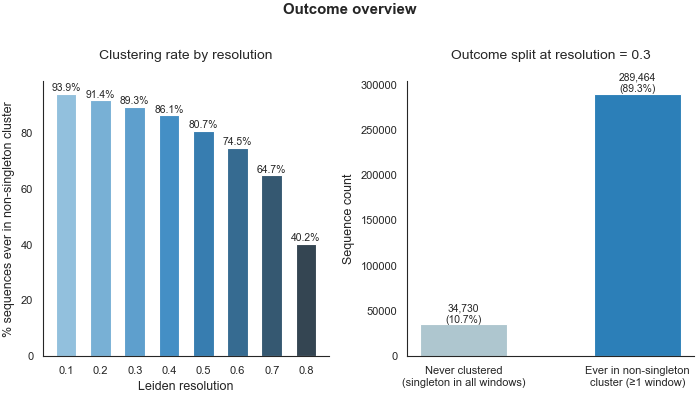


Summary by resolution:
 resolution  n_clustered  n_total       pct
        0.1       304288   324194 93.859849
        0.2       296437   324194 91.438151
        0.3       289464   324194 89.287279
        0.4       279161   324194 86.109243
        0.5       261530   324194 80.670833
        0.6       241482   324194 74.486881
        0.7       209871   324194 64.736238
        0.8       130312   324194 40.195685


In [9]:
# Clustering rate by resolution — does it change monotonically?
rate_res = (
    adf.groupby("resolution")["ever_clustered"]
    .agg(n_clustered="sum", n_total="count")
    .assign(pct=lambda d: 100 * d["n_clustered"] / d["n_total"])
    .reset_index()
)

fig, axes = st.new_figure("double", height_in=4, ncols=2)

# (a) Proportion ever clustered by resolution
ax = axes[0]
bars = ax.bar(rate_res["resolution"].astype(str), rate_res["pct"],
              color=sns.color_palette("Blues_d", len(rate_res)), width=0.6)
ax.set_xlabel("Leiden resolution")
ax.set_ylabel("% sequences ever in non-singleton cluster")
ax.set_title("Clustering rate by resolution", y=1.05)
for bar, pct in zip(bars, rate_res["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize="small")

# (b) Overall outcome split at working resolution
ax = axes[1]
working = adf[adf["resolution"] == WORKING_RES].copy()
counts = working["ever_clustered"].value_counts().sort_index()
labels = ["Never clustered\n(singleton in all windows)", f"Ever in non-singleton\ncluster (≥1 window)"]
ax.bar(labels, counts.values, color=["#aec6cf", "#2c7fb8"], width=0.5)
ax.set_ylabel("Sequence count")
ax.set_title(f"Outcome split at resolution = {WORKING_RES}", y=1.05)
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({100*v/counts.sum():.1f}%)",
            ha="center", va="bottom", fontsize="small")

plt.suptitle("Outcome overview", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nSummary by resolution:")
print(rate_res.to_string(index=False))

In [11]:
# All subsequent EDA uses the working resolution for clarity.
# §10 examines whether findings are consistent across all resolutions.
wd = working.copy()
print(f"Working dataset (resolution = {WORKING_RES}): {len(wd):,} sequences")
print(f"Overall clustering rate: {wd['ever_clustered'].mean():.3f}")

Working dataset (resolution = 0.3): 324,194 sequences
Overall clustering rate: 0.893


## 4  Exposure: SIMD quintile

`dz_simd_quintile` is ordinal 1–5 (1 = most deprived, 5 = least).
Key questions:
- Is the distribution reasonably balanced across quintiles?
- Is there a monotone gradient in clustering probability across quintiles?
- Does the relationship look linear on the log-odds scale (i.e. is a single linear term sufficient, or do we need dummies or a polynomial)?

The **Cochran–Armitage–style trend test** is computed as the Wald test on the slope in
`logit(ever_clustered) ~ dz_simd_quintile` — a significant p-value supports a linear trend.
A significant quadratic term in `~ dz_simd_quintile + I(dz_simd_quintile**2)` would suggest
non-linearity.


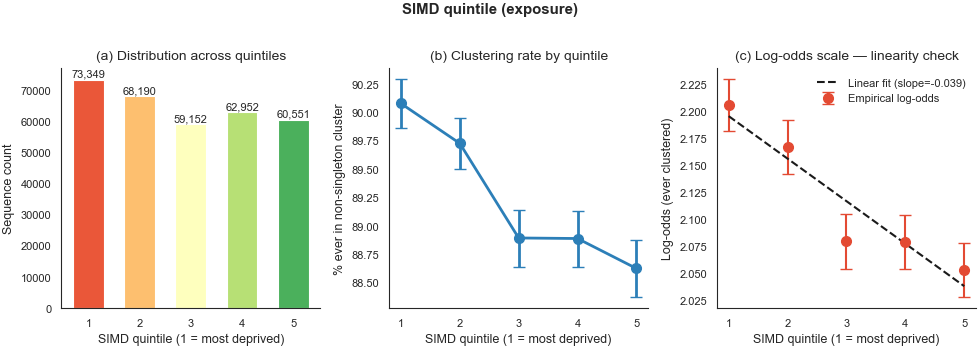

,dz_simd_quintile,sum,count,p,lo,hi,logodds,lo_lo,hi_lo
0,1,66073,73349,0.900803,0.898619,0.902945,2.206179,2.181970,2.230388
1,2,61186,68190,0.897287,0.894986,0.899543,2.167437,2.142714,2.192160
2,3,52583,59152,0.888947,0.886390,0.891454,2.080031,2.054383,2.105679
3,4,55958,62952,0.888899,0.886421,0.891331,2.079549,2.054691,2.104406
4,5,53664,60551,0.886261,0.883708,0.888766,2.053107,2.028020,2.078194


In [22]:
fig, axes = st.new_figure(width_in=10, height_in=3.5, ncols=3)

# (a) Distribution of sequences across quintiles
ax = axes[0]
counts_q = wd["dz_simd_quintile"].value_counts().sort_index()
ax.bar(counts_q.index.astype(str), counts_q.values,
       color=sns.color_palette("RdYlGn", 5), width=0.6, edgecolor="white")
ax.set_xlabel("SIMD quintile (1 = most deprived)")
ax.set_ylabel("Sequence count")
ax.set_title("(a) Distribution across quintiles")
for x, v in zip(counts_q.index, counts_q.values):
    ax.text(x - 1, v + 100, f"{v:,}", ha="center", va="bottom", fontsize=8)

# (b) Empirical clustering rate per quintile with 95% Wilson CI
ax = axes[1]
grp = wd.groupby("dz_simd_quintile")["ever_clustered"].agg(["sum", "count"]).reset_index()
grp["p"]  = grp["sum"] / grp["count"]
# Wilson CI
z = 1.96
grp["lo"] = (
    (grp["p"] + z**2/(2*grp["count"]) -
     z * np.sqrt(grp["p"]*(1-grp["p"])/grp["count"] +
                 z**2 / (4*grp["count"]**2))) / (1 + z**2/grp["count"])
)
grp["hi"] = (
    (grp["p"] + z**2/(2*grp["count"]) +
     z * np.sqrt(grp["p"]*(1-grp["p"])/grp["count"] +
                 z**2 / (4*grp["count"]**2))) / (1 + z**2/grp["count"])
)

ax.errorbar(grp["dz_simd_quintile"], 100*grp["p"],
            yerr=[100*(grp["p"]-grp["lo"]), 100*(grp["hi"]-grp["p"])],
            fmt="o-", color="#2c7fb8", capsize=4, lw=2, ms=7)

ax.set_xlabel("SIMD quintile (1 = most deprived)")
ax.set_ylabel("% ever in non-singleton cluster")
ax.set_title("(b) Clustering rate by quintile")
ax.set_xticks([1,2,3,4,5])

# (c) Log-odds scale (for logit-linearity assessment)
ax = axes[2]
grp["logodds"] = np.log(grp["p"] / (1 - grp["p"]))
grp["lo_lo"]   = np.log(grp["lo"] / (1 - grp["lo"]))
grp["hi_lo"]   = np.log(grp["hi"] / (1 - grp["hi"]))
ax.errorbar(grp["dz_simd_quintile"], grp["logodds"],
            yerr=[grp["logodds"]-grp["lo_lo"], grp["hi_lo"]-grp["logodds"]],
            fmt="o", color="#e34a33", capsize=4, ms=7, label="Empirical log-odds")
# Linear fit
coef = np.polyfit(grp["dz_simd_quintile"], grp["logodds"], 1)
x_fit = np.linspace(1, 5, 100)
ax.plot(x_fit, np.polyval(coef, x_fit), "k--", lw=1.5, label=f"Linear fit (slope={coef[0]:.3f})")
ax.set_xlabel("SIMD quintile (1 = most deprived)")
ax.set_ylabel("Log-odds (ever clustered)")
ax.set_title("(c) Log-odds scale — linearity check")
ax.set_xticks([1,2,3,4,5])
ax.legend(loc="upper right")

plt.suptitle("SIMD quintile (exposure)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
display(grp)

In [28]:
# Formal trend test: Wald p-value on linear SIMD term
d_trend = wd[["ever_clustered", "dz_simd_quintile"]].dropna()
m_lin  = smf.logit("ever_clustered ~ dz_simd_quintile", data=d_trend).fit(disp=0)
m_quad = smf.logit("ever_clustered ~ dz_simd_quintile + I(dz_simd_quintile**2)", data=d_trend).fit(disp=0)

print("── Linear trend test ──────────────────────────────────────────────────────")
print(f"  Slope (per quintile increase) : OR = {np.exp(m_lin.params['dz_simd_quintile']):.3f}")
ci = np.exp(m_lin.conf_int().loc["dz_simd_quintile"])
print(f"  95% CI                        : ({ci[0]:.3f}, {ci[1]:.3f})")
print(f"  Wald p                        : {m_lin.pvalues['dz_simd_quintile']:.2e}")

print("\n── Quadratic deviation test ───────────────────────────────────────────────")
print(f"  p (quadratic term)            : {m_quad.pvalues['I(dz_simd_quintile ** 2)']:.3f}")
lrt = 2 * (m_quad.llf - m_lin.llf)
lrt_p = stats.chi2.sf(lrt, df=1)
print(f"  LRT vs linear (df=1)          : χ² = {lrt:.2f}, p = {lrt_p:.3f}")
print()
print("If LRT p > 0.05 → linear SIMD term is adequate.")
print("If LRT p < 0.05 → consider quintile dummies or spline on continuous rank.")

print("\nPredicted probability per quintile under each model:")
for q in [1,2,3,4,5]:
    p_lin = m_lin.predict(pd.DataFrame({"dz_simd_quintile": [q]}))[0]
    p_dum = m_dum.predict(pd.DataFrame({"dz_simd_quintile": [q]}))[0]
    print(f"Q{q}: linear={100*p_lin:.3f}%  dummies={100*p_dum:.3f}%  Δ={100*(p_dum-p_lin):.3f}pp")

── Linear trend test ──────────────────────────────────────────────────────
  Slope (per quintile increase) : OR = 0.961
  95% CI                        : (0.954, 0.969)
  Wald p                        : 1.89e-23

── Quadratic deviation test ───────────────────────────────────────────────
  p (quadratic term)            : 0.024
  LRT vs linear (df=1)          : χ² = 5.08, p = 0.024

If LRT p > 0.05 → linear SIMD term is adequate.
If LRT p < 0.05 → consider quintile dummies or spline on continuous rank.

Predicted probability per quintile under each model:
Q1: linear=89.998%  dummies=90.080%  Δ=0.082pp
Q2: linear=89.637%  dummies=89.729%  Δ=0.092pp
Q3: linear=89.263%  dummies=88.895%  Δ=-0.369pp
Q4: linear=88.878%  dummies=88.890%  Δ=0.012pp
Q5: linear=88.481%  dummies=88.626%  Δ=0.145pp


"A quadratic sensitivity analysis confirmed that departures from linearity were negligible (maximum predicted probability difference 0.37 percentage points at Q3); the linear parameterisation was retained."

## 5  Continuous covariates — linearity checks

For each continuous covariate the left panel shows its distribution (histogram) and the
right panel shows the **empirical log-odds** of `ever_clustered` across equal-frequency
decile bins, with a LOWESS smoother (red) and a linear fit (dashed black).

**How to read these plots:**
- If LOWESS ≈ linear fit → logit-linear assumption holds → use variable as-is.
- If LOWESS curves away from the linear fit → consider log-transformation, restricted
  cubic spline (e.g. `bs(x, df=4)` in statsmodels), or categorisation.
- A flat LOWESS → weak or no marginal association; check if the variable is still needed
  as a confounder (theory-driven inclusion may still be appropriate).

Variables assessed:

| Variable | Role | Notes |
|---|---|---|
| `age_midpoint` | Demographics | Likely non-linear (older → less community exposure) |
| `vacc_dose_number` | Vaccination | Ordinal 0–4; check dose-response |
| `days_since_vaccination` | Vaccination | Only for vaccinated; may need log or spline |
| `dz_population_density` | Structural | Highly right-skewed → always log-transform |
| `dz_cum_prop_sequenced` | Surveillance intensity | Critical confounder; bounded 0–1 |
| `wn_prop_sequenced_mean` | Surveillance intensity | Window-level denominator |
| `dz_cum_incidence_per_capita` | Epidemic burden (DZ) | Right-skewed |
| `dz_7d_test_positivity` | Epidemic burden (DZ) | Bounded 0–1 |
| `window_idx_min` | Epidemic phase | Non-linear (wave structure) — use spline or dummies |
| `n_windows` | Opportunity | More windows → more chance to be seen in a cluster |


In [30]:
def binned_logodds_plot(data, var, outcome="ever_clustered", n_bins=N_BINS,
                         log_transform=False, ax=None, title=None, min_obs=MIN_BIN_N):
    """
    Bin `var` into equal-frequency groups, compute empirical log-odds of `outcome`
    per bin, overlay LOWESS smoother and linear fit.
    Residual from linear fit ≈ 0 → logit-linear assumption tenable.
    """
    d = data[[var, outcome]].dropna().copy()
    if d.empty or d[var].nunique() < 3:
        if ax: ax.text(0.5, 0.5, "insufficient data", transform=ax.transAxes, ha="center")
        return ax

    x = np.log1p(d[var].clip(lower=0)) if log_transform else d[var]

    try:
        d["_bin"] = pd.qcut(x, n_bins, duplicates="drop")
    except Exception:
        d["_bin"] = pd.cut(x, max(n_bins // 2, 3))

    grp = d.groupby("_bin")[outcome].agg(["sum", "count"]).reset_index()
    grp = grp[grp["count"] >= min_obs].copy()
    if grp.empty:
        return ax

    # Add-0.5 smoothing avoids log(0)
    grp["p"]      = (grp["sum"] + 0.5) / (grp["count"] + 1)
    grp["logodds"] = np.log(grp["p"] / (1 - grp["p"]))
    grp["se"]     = np.sqrt(1/(grp["sum"]+0.5) + 1/(grp["count"]-grp["sum"]+0.5))
    grp["mid"]    = grp["_bin"].apply(lambda b: (b.left + b.right) / 2)

    if ax is None:
        _, ax = st.new_figure("single")

    ax.errorbar(grp["mid"], grp["logodds"], yerr=1.96*grp["se"],
                fmt="o", ms=4, color="#2c7fb8", capsize=3, lw=1, zorder=3,
                label="Empirical log-odds ± 95% CI")

    if len(grp) >= 4:
        sm_out = lowess(grp["logodds"], grp["mid"], frac=0.65, return_sorted=True)
        ax.plot(sm_out[:, 0], sm_out[:, 1], color="#e34a33", lw=2, label="LOWESS")

    if len(grp) >= 3:
        valid = grp[["mid", "logodds"]].dropna()
        coef  = np.polyfit(valid["mid"], valid["logodds"], 1)
        xl    = np.linspace(valid["mid"].min(), valid["mid"].max(), 100)
        ax.plot(xl, np.polyval(coef, xl), "k--", lw=1.2, alpha=0.7, label="Linear fit")

    xlabel = f"log(1 + {var})" if log_transform else var
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Log-odds", fontsize=8)
    ax.set_title(title or var, fontsize=9, pad=3)
    ax.tick_params(labelsize=7)
    return ax

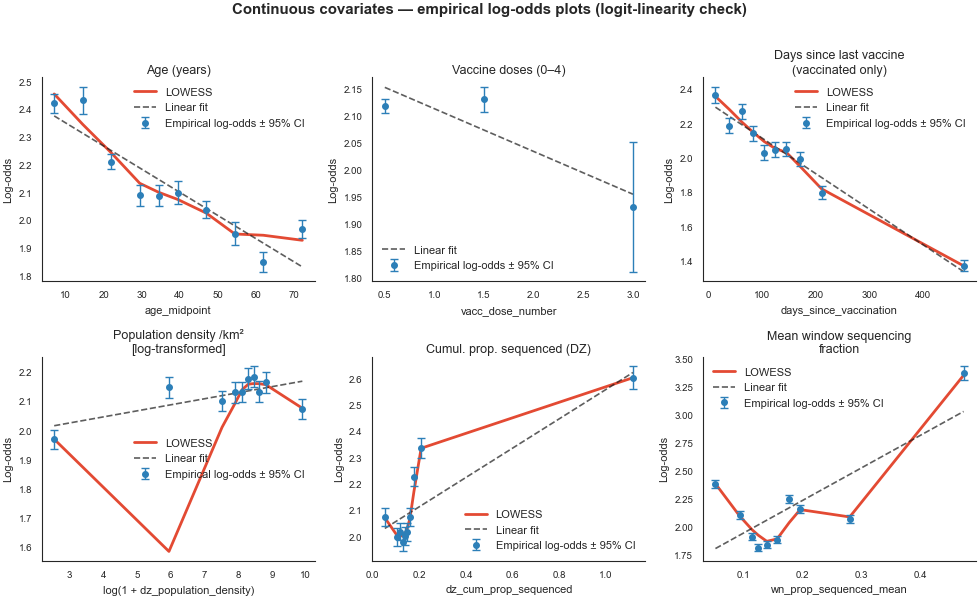

Interpretation guide: LOWESS hugging the dashed linear fit → logit-linearity OK.
Curved LOWESS departing from linear fit → consider log/spline/categorisation.


In [38]:
CONT_VARS = [
    # (column,              display_name,                       log_transform?)
    ("age_midpoint",         "Age (years)",                      False),
    ("vacc_dose_number",     "Vaccine doses (0–4)",             False),
    ("days_since_vaccination","Days since last vaccine\n(vaccinated only)", False),
    ("dz_population_density","Population density /km²\n[log-transformed]", True),
    ("dz_cum_prop_sequenced","Cumul. prop. sequenced (DZ)",      False),
    ("wn_prop_sequenced_mean","Mean window sequencing\nfraction", False),
    ("dz_cum_incidence_per_capita","Cumul. incidence per capita (DZ)", False),
    ("dz_7d_test_positivity","7-day test positivity (DZ)",       False),
    ("window_idx_min",       "Earliest window index\n(epidemic phase)", False),
    ("n_windows",            "No. eligible windows\n(opportunity covariate)", False),
]

fig, axes = st.new_figure(width_in=10, height_in=6, ncols=3, nrows=2)
axes = axes.flatten()

for ax, (var, name, log_t) in zip(axes, CONT_VARS):
    d = wd[[var, "ever_clustered"]].dropna()
    if d.empty:
        ax.set_visible(False)
        continue
    binned_logodds_plot(d, var, log_transform=log_t, ax=ax, title=name)
    ax.legend()

plt.suptitle(
    "Continuous covariates — empirical log-odds plots (logit-linearity check)",
    fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()
print("Interpretation guide: LOWESS hugging the dashed linear fit → logit-linearity OK.")
print("Curved LOWESS departing from linear fit → consider log/spline/categorisation.")


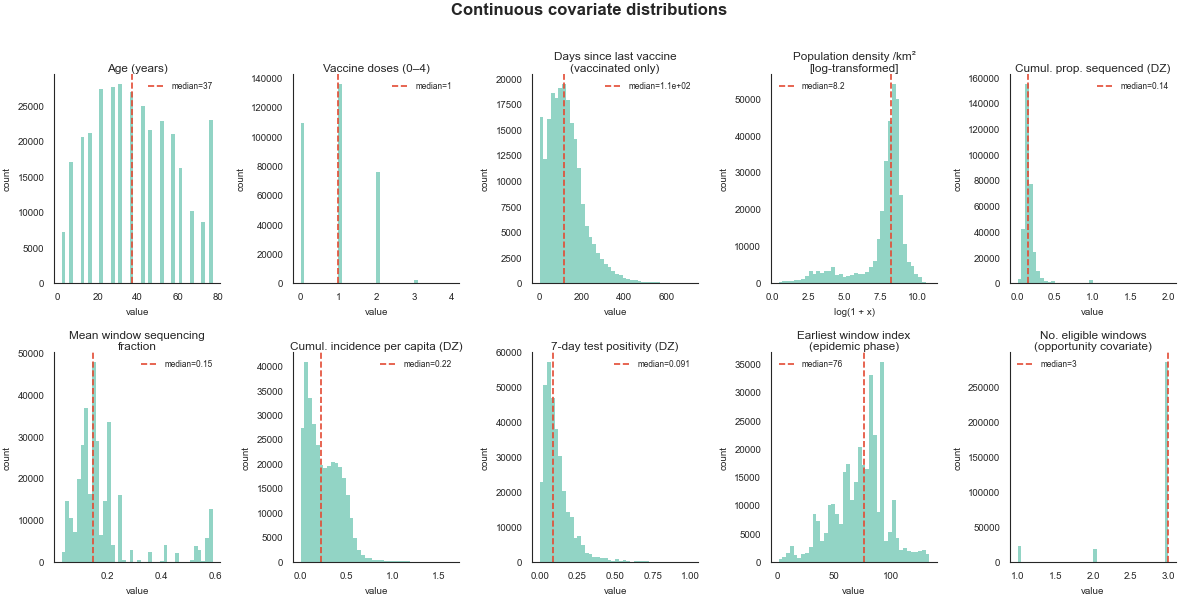

In [39]:
# ── Distributions of continuous covariates ─────────────────────────────────────
fig, axes = st.new_figure(width_in=12, height_in=6, ncols=5, nrows=2)
axes = axes.flatten()

for ax, (var, name, log_t) in zip(axes, CONT_VARS):
    d = wd[var].dropna()
    if d.empty:
        ax.set_visible(False)
        continue
    x = np.log1p(d.clip(lower=0)) if log_t else d
    ax.hist(x, bins=40, color="#7fcdbb", edgecolor="none", alpha=0.85)
    ax.set_title(name, fontsize=8.5, pad=2)
    ax.set_xlabel("log(1 + x)" if log_t else "value", fontsize=7)
    ax.set_ylabel("count", fontsize=7)
    ax.tick_params(labelsize=7)
    # Add median line
    ax.axvline(x.median(), color="#e34a33", lw=1.2, ls="--", label=f"median={x.median():.2g}")
    ax.legend(fontsize=6)

plt.suptitle("Continuous covariate distributions", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6  Binary covariates

For each binary covariate we report:
- Prevalence in the working dataset
- Unadjusted OR for `ever_clustered` with 95% CI


In [43]:
print(wd["vacc_booster"].value_counts())

vacc_booster
TRUE     108172
FALSE    106376
             42
Name: count, dtype: int64


In [47]:
wd["vacc_booster"] = wd["vacc_booster"].fillna(0).astype(bool)

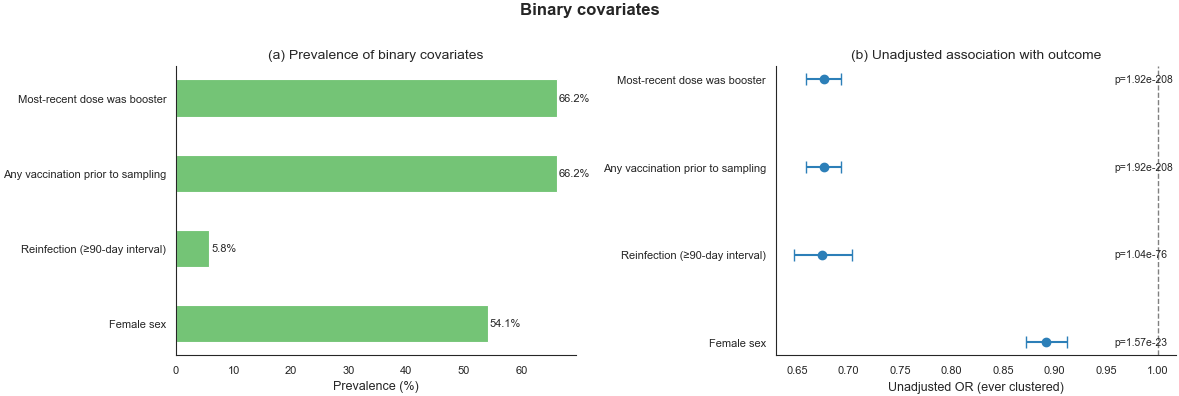

                         variable      n  prev    OR    lo    hi   p
                       Female sex 324194 0.541 0.892 0.872 0.912 0.0
   Reinfection (≥90-day interval) 324194 0.058 0.675 0.647 0.703 0.0
Any vaccination prior to sampling 324194 0.662 0.676 0.659 0.693 0.0
     Most-recent dose was booster 324194 0.662 0.676 0.659 0.693 0.0


In [50]:
BINARY_VARS = [
    ("is_female",       "Female sex"),
    ("is_reinfection",  "Reinfection (≥90-day interval)"),
    ("is_vaccinated",   "Any vaccination prior to sampling"),
    ("vacc_booster",    "Most-recent dose was booster"),
]

results_bin = []
for col, label in BINARY_VARS:
    if col not in wd.columns:
        continue
    d = wd[[col, "ever_clustered"]].dropna()
    n1   = (d[col] == 1).sum()
    prev = n1 / len(d)
    ct   = pd.crosstab(d[col], d["ever_clustered"])
    if ct.shape == (2, 2):
        or_val = (ct.iloc[1,1] * ct.iloc[0,0]) / (ct.iloc[1,0] * ct.iloc[0,1])
        # Woolf logit CI
        se_log = np.sqrt(sum(1/v for v in ct.values.flatten() if v > 0))
        lo = np.exp(np.log(or_val) - 1.96*se_log)
        hi = np.exp(np.log(or_val) + 1.96*se_log)
        chi2, p, _, _ = chi2_contingency(ct, correction=False)
    else:
        or_val = lo = hi = p = np.nan
    results_bin.append({"variable": label, "n": len(d), "prev": prev,
                         "OR": or_val, "lo": lo, "hi": hi, "p": p})

df_bin = pd.DataFrame(results_bin)

fig, axes = st.new_figure(width_in=12, height_in=4,  ncols=2)

# (a) Prevalence
ax = axes[0]
ax.barh(df_bin["variable"], 100*df_bin["prev"], color="#74c476", height=0.5)
ax.set_xlabel("Prevalence (%)")
ax.set_title("(a) Prevalence of binary covariates")
for i, row in df_bin.iterrows():
    ax.text(100*row["prev"]+0.3, i, f"{100*row['prev']:.1f}%", va="center", fontsize=8)

# (b) Unadjusted OR forest plot
ax = axes[1]
y = range(len(df_bin))
ax.errorbar(df_bin["OR"], y,
            xerr=[df_bin["OR"]-df_bin["lo"], df_bin["hi"]-df_bin["OR"]],
            fmt="o", color="#2c7fb8", capsize=4, ms=6, lw=1.5)
ax.axvline(1, color="grey", lw=1, ls="--")
ax.set_yticks(list(y))
ax.set_yticklabels(df_bin["variable"])
ax.set_xlabel("Unadjusted OR (ever clustered)")
ax.set_title("(b) Unadjusted association with outcome")
# Annotate p-values
for i, row in df_bin.iterrows():
    p_str = f"p={row['p']:.2e}" if row["p"] < 0.001 else f"p={row['p']:.3f}"
    ax.text(df_bin["hi"].max()*1.05, i, p_str, va="center", fontsize=7.5)

plt.suptitle("Binary covariates", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print(df_bin[["variable","n","prev","OR","lo","hi","p"]].round(3).to_string(index=False))


## 7  Categorical covariates

For each multi-level categorical variable we plot the **empirical clustering rate** per
category (sorted descending) with 95% Wilson confidence intervals, and report an
overall χ² test of association.

Key considerations:
- **`who_voc`** — confounds by time (variants succeeded one another); include as a fixed effect or use `clade` for finer resolution
- **`test_reason`** — substantial missingness; decide whether to include or treat NaN as a category
- **`dz_urban_rural_class`** — 6-level; correlated with SIMD and density (check §8 collinearity)
- **`dz_health_board`** — 14 Health Boards; use as fixed or random effect depending on model framework


In [51]:
def categorical_rate_plot(data, var, outcome="ever_clustered", ax=None,
                           title=None, max_cats=20):
    """
    Sorted horizontal bar chart of outcome rate per category with 95% Wilson CI.
    Returns (ax, chi2_stat, p_value).
    """
    d = data[[var, outcome]].dropna()
    grp = d.groupby(var)[outcome].agg(["sum", "count"]).reset_index()
    grp["p"]  = grp["sum"] / grp["count"]
    z = 1.96
    grp["lo"] = (grp["p"] + z**2/(2*grp["count"]) -
                 z*np.sqrt(grp["p"]*(1-grp["p"])/grp["count"] + z**2/(4*grp["count"]**2))) /                 (1 + z**2/grp["count"])
    grp["hi"] = (grp["p"] + z**2/(2*grp["count"]) +
                 z*np.sqrt(grp["p"]*(1-grp["p"])/grp["count"] + z**2/(4*grp["count"]**2))) /                 (1 + z**2/grp["count"])
    grp = grp.sort_values("p", ascending=True).tail(max_cats)

    ct   = pd.crosstab(d[var], d[outcome])
    chi2, p_val = (np.nan, np.nan)
    if ct.shape[1] == 2:
        chi2, p_val, _, _ = chi2_contingency(ct)

    if ax is None:
        _, ax = plt.subplots()
        _, ax = st.new_figure("single")

    ax.barh(grp[var].astype(str), 100*grp["p"], color="#9ecae1", height=0.6)
    ax.errorbar(100*grp["p"], grp[var].astype(str),
                xerr=[100*(grp["p"]-grp["lo"]), 100*(grp["hi"]-grp["p"])],
                fmt="none", color="#2c7fb8", capsize=3, lw=1.2)
    overall = 100 * d[outcome].mean()
    ax.axvline(overall, color="#e34a33", ls="--", lw=1.2, label=f"Overall: {overall:.1f}%")
    ax.set_xlabel("% ever clustered")
    ax.set_title((title or var) + f"  [χ²={chi2:.1f}, p={p_val:.2e}]" if not np.isnan(chi2)
                 else (title or var), fontsize=9)
    ax.legend(fontsize=7)
    return ax, chi2, p_val


In [56]:
# # ── Test characteristics ───────────────────────────────────────────────────────
# fig, axes = st.new_figure(width_in=12, height_in=4,  ncols=2)
# categorical_rate_plot(wd, "test_type",   ax=axes[0], title="Test type")
# categorical_rate_plot(wd, "test_reason", ax=axes[1], title="Test reason")
# plt.suptitle("Test characteristics", fontsize=11, fontweight="bold")
# plt.tight_layout()
# plt.show()


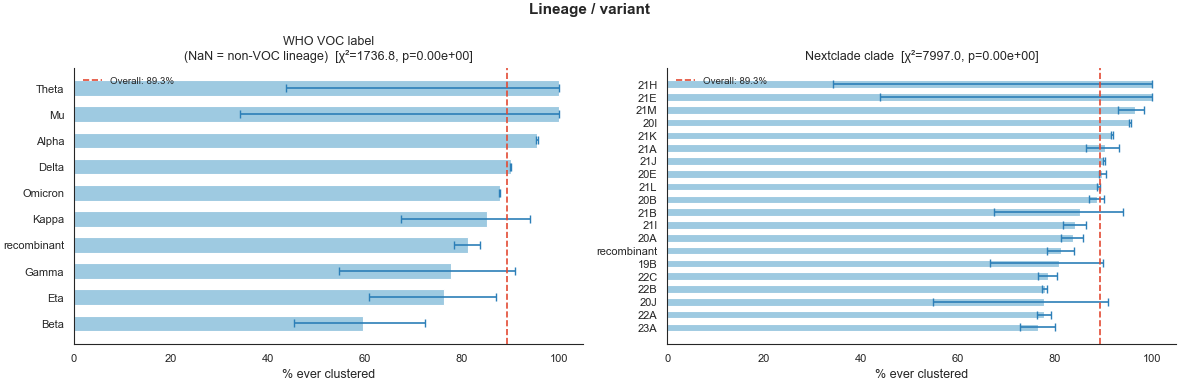

In [57]:
# ── Lineage / variant ──────────────────────────────────────────────────────────
fig, axes = st.new_figure(width_in=12, height_in=4,  ncols=2)
categorical_rate_plot(wd, "who_voc", ax=axes[0], title="WHO VOC label\n(NaN = non-VOC lineage)")
categorical_rate_plot(wd, "clade",   ax=axes[1], title="Nextclade clade", max_cats=20)
plt.suptitle("Lineage / variant", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

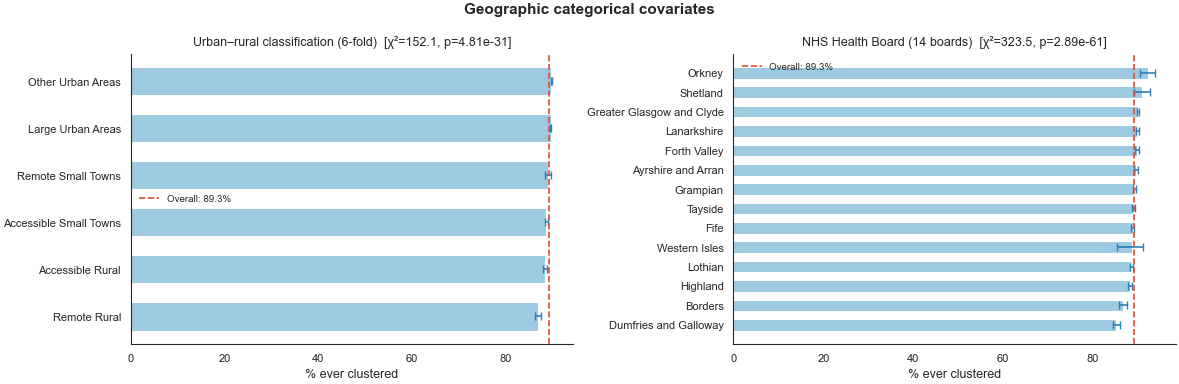

In [58]:
# ── Geographic classification ──────────────────────────────────────────────────
fig, axes = st.new_figure(width_in=12, height_in=4,  ncols=2)
categorical_rate_plot(wd, "dz_urban_rural_class", ax=axes[0], title="Urban–rural classification (6-fold)")
categorical_rate_plot(wd, "dz_health_board",      ax=axes[1], title="NHS Health Board (14 boards)")
plt.suptitle("Geographic categorical covariates", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [62]:
print(wd["vacc_product_name"].value_counts())

vacc_product_name
Covid-19 mRNA Vaccine Pfizer                       130010
Covid-19 Vaccine AstraZeneca                        44973
Covid-19 mRNA Vaccine Moderna                       33401
Covid-19 mRNA Vaccine Spikevax Bivalent Moderna      2691
Covid-19 mRNA Vaccine Comirnaty Bivalent Pfizer      1558
COVID-19 Vaccine                                     1508
Covid-19 mRNA Vaccine Pfizer (Children)               349
Covid-19 Vaccine Novavax                               39
Covid-19 Vaccine Janssen                               27
Covid-19 Vaccine Valneva                               24
Covid-19 Vaccine Medicago                               5
Covid-19 Vaccine Sinopharm injection vials BIBP         4
Covid-19 Vaccine AstraZeneca AB                         1
Name: count, dtype: int64


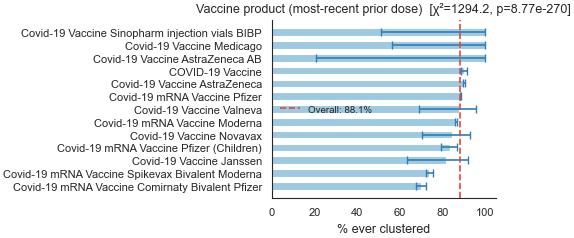

In [59]:
# ── Vaccination product ────────────────────────────────────────────────────────
if "vacc_product_name" in wd.columns:
    fig, ax = st.new_figure("onehalf")
    categorical_rate_plot(wd, "vacc_product_name", ax=ax,
                           title="Vaccine product (most-recent prior dose)")
    plt.tight_layout()
    plt.show()

## 8  High-dimensional covariate: Pango lineage

`pango_lineage` has hundreds of levels and is highly collinear with `who_voc`, `clade`,
and `window_idx_min` (variants succeeded one another over time).

Key diagnostic: is there substantial **residual variance** in clustering probability
*within* WHO VOC groups across fine lineages? If yes, including `pango_lineage` fixed
effects (or at minimum `clade`) is warranted.

**Practical options in the model:**
1. Use `who_voc` + `clade` (recommended — reduces dimensionality, still captures variant-era differences)
2. Regularised lineage fixed effects (LASSO / ridge logistic) if fine-grained control is needed
3. Include `pango_lineage` as a random effect `(1|pango_lineage)` in a mixed model


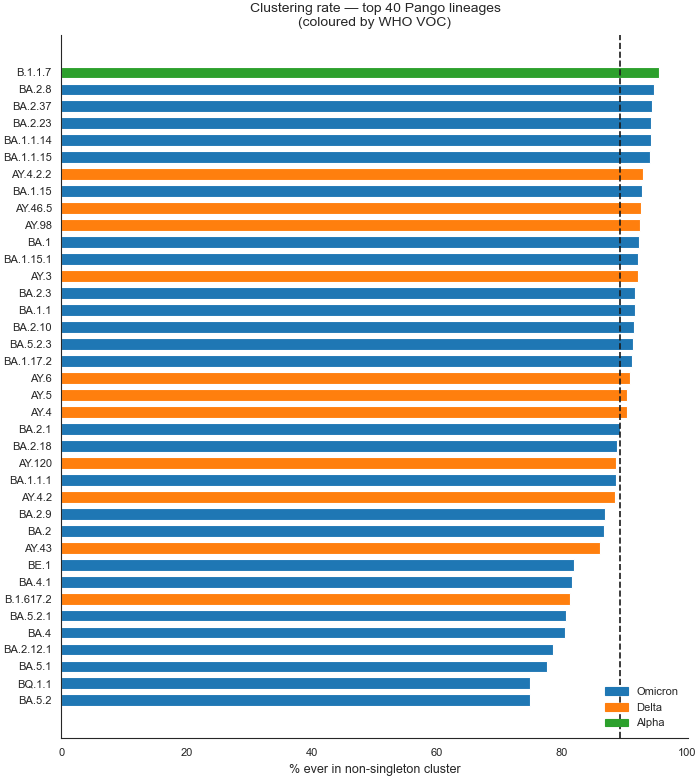


Std dev of lineage-specific clustering rates (top 40): 0.0584
High std → lineage is an important confounder; include clade/who_voc at minimum.


In [63]:
# Variance in clustering rate across the top-N most common lineages
TOP_N = 40

top_lineages = wd["pango_lineage"].value_counts().head(TOP_N).index
d_lin = wd[wd["pango_lineage"].isin(top_lineages)].copy()

lin_grp = (
    d_lin.groupby(["pango_lineage", "who_voc"])["ever_clustered"]
    .agg(["sum", "count"])
    .assign(p=lambda d: d["sum"] / d["count"])
    .reset_index()
    .sort_values("p")
)

# Colour by WHO VOC
voc_labels = lin_grp["who_voc"].fillna("Non-VOC")
palette = dict(zip(voc_labels.unique(), sns.color_palette("tab10", voc_labels.nunique())))
colours = voc_labels.map(palette)

fig, ax = st.new_figure("double", height_in=8)
ax.barh(lin_grp["pango_lineage"], 100*lin_grp["p"], color=colours.values, height=0.7)
ax.axvline(100*wd["ever_clustered"].mean(), color="k", ls="--", lw=1.2, label="Overall mean")
ax.set_xlabel("% ever in non-singleton cluster")
ax.set_title(f"Clustering rate — top {TOP_N} Pango lineages\n(coloured by WHO VOC)", fontsize=10)

# Legend for VOC colours
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nStd dev of lineage-specific clustering rates (top {TOP_N}): "
      f"{lin_grp['p'].std():.4f}")
print("High std → lineage is an important confounder; include clade/who_voc at minimum.")


## 9  Collinearity

Three complementary diagnostics:

| Diagnostic | Variables | Concern threshold |
|---|---|---|
| Spearman ρ heatmap | Continuous & ordinal | |ρ| > 0.7 |
| Cramér's V heatmap | Categorical (pairs) | V > 0.5 |
| Variance Inflation Factor (VIF) | All (design matrix) | VIF > 10 critical; > 5 worth noting |

**Variables most expected to be collinear with SIMD quintile:**
`dz_population_density`, `dz_urban_rural_class`, `dz_simd_*_rank` domain sub-indices.


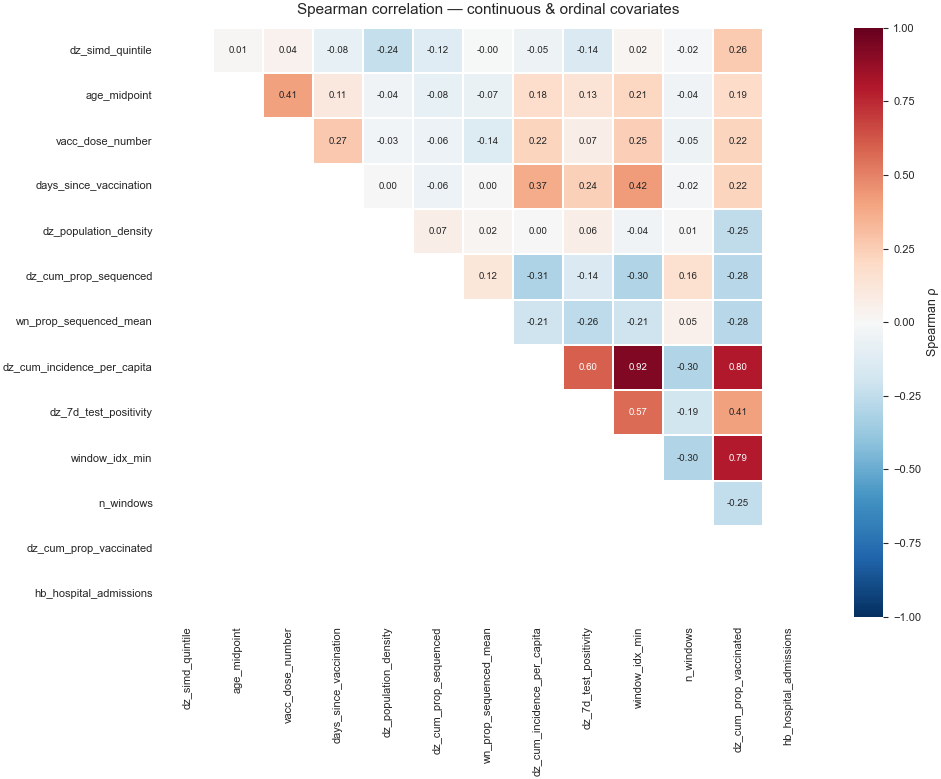

Correlations with dz_simd_quintile:
dz_cum_prop_vaccinated         0.262
dz_population_density         -0.237
dz_7d_test_positivity         -0.142
dz_cum_prop_sequenced         -0.125
days_since_vaccination        -0.079
dz_cum_incidence_per_capita   -0.048
vacc_dose_number               0.044
window_idx_min                 0.016
n_windows                     -0.015
age_midpoint                   0.011
wn_prop_sequenced_mean        -0.000
hb_hospital_admissions           NaN

|ρ| > 0.50 suggests potential collinearity with the exposure.


In [64]:
# ── Spearman correlation matrix (continuous + ordinal) ─────────────────────────
CONT_COLS = [
    "dz_simd_quintile",
    "age_midpoint",
    "vacc_dose_number",
    "days_since_vaccination",
    "dz_population_density",
    "dz_cum_prop_sequenced",
    "wn_prop_sequenced_mean",
    "dz_cum_incidence_per_capita",
    "dz_7d_test_positivity",
    "window_idx_min",
    "n_windows",
    "dz_cum_prop_vaccinated",
    "hb_hospital_admissions",
]
CONT_COLS = [c for c in CONT_COLS if c in wd.columns]

corr_mat = wd[CONT_COLS].apply(pd.to_numeric, errors="coerce").corr(method="spearman")

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

fig, ax = st.new_figure(width_in=10, height_in=8)
sns.heatmap(
    corr_mat, mask=~mask,      # show lower triangle
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    linewidths=0.3, ax=ax,
    cbar_kws={"label": "Spearman ρ"},
)
ax.set_title("Spearman correlation — continuous & ordinal covariates", fontsize=11, pad=10)
plt.tight_layout()
plt.show()

# Flag high correlations with the exposure
print("Correlations with dz_simd_quintile:")
with_simd = corr_mat["dz_simd_quintile"].drop("dz_simd_quintile").sort_values(key=abs, ascending=False)
print(with_simd.round(3).to_string())
print("\n|ρ| > 0.50 suggests potential collinearity with the exposure.")


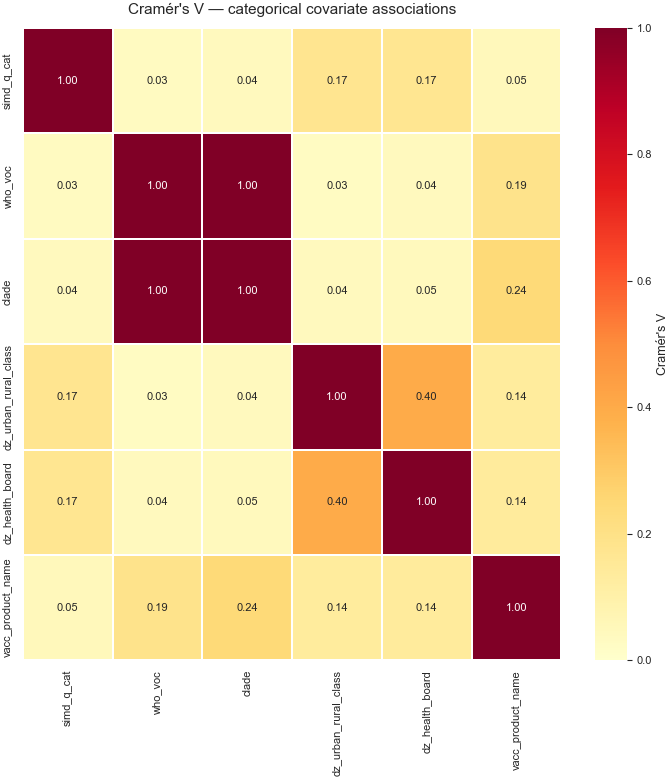

,simd_q_cat,who_voc,clade,dz_urban_rural_class,dz_health_board,vacc_product_name
simd_q_cat,1.000000,0.033081,0.039308,0.173710,0.170619,0.047132
who_voc,0.033081,1.000000,0.999970,0.029272,0.040226,0.188421
clade,0.039308,0.999970,1.000000,0.039771,0.045333,0.242679
dz_urban_rural_class,0.173710,0.029272,0.039771,1.000000,0.398671,0.136539
dz_health_board,0.170619,0.040226,0.045333,0.398671,1.000000,0.137681
vacc_product_name,0.047132,0.188421,0.242679,0.136539,0.137681,1.000000


V > 0.50: substantial association; V > 0.70: strong (watch for separation or redundancy).


In [66]:
# ── Cramér's V — categorical × categorical ────────────────────────────────────
def cramers_v(x, y):
    """Cramér's V for two categorical Series (NaN-dropped)."""
    d = pd.concat([x, y], axis=1).dropna()
    if d.empty or d.iloc[:,0].nunique() < 2 or d.iloc[:,1].nunique() < 2:
        return np.nan
    ct   = pd.crosstab(d.iloc[:,0], d.iloc[:,1])
    chi2 = chi2_contingency(ct, correction=False)[0]
    n    = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(max(phi2 - (k-1)*(r-1)/((n-1)), 0) /
                   min(k-1, r-1))

CAT_COLS = [c for c in [
    "who_voc", "clade", "dz_urban_rural_class", "dz_health_board",
    "test_type", "test_reason", "vacc_product_name",
] if c in wd.columns]

# Also treat SIMD quintile as categorical for this matrix
wd["simd_q_cat"] = wd["dz_simd_quintile"].astype("Int64").astype(str)
CAT_COLS_FULL = ["simd_q_cat"] + CAT_COLS

v_mat = pd.DataFrame(index=CAT_COLS_FULL, columns=CAT_COLS_FULL, dtype=float)
for c1 in CAT_COLS_FULL:
    for c2 in CAT_COLS_FULL:
        v_mat.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(wd[c1], wd[c2])

fig, ax = st.new_figure("double", height_in=8)
sns.heatmap(
    v_mat.astype(float),
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="YlOrRd", vmin=0, vmax=1,
    linewidths=0.3, ax=ax,
    cbar_kws={"label": "Cramér's V"},
)
ax.set_title("Cramér's V — categorical covariate associations", fontsize=11, pad=10)
plt.tight_layout()
plt.show()
display(v_mat)
print("V > 0.50: substantial association; V > 0.70: strong (watch for separation or redundancy).")

In [67]:
# ── VIF — design matrix for the planned model ─────────────────────────────────
# Construct a numeric design matrix approximating the full model.
# Categorical variables are dummy-coded; random effects not captured here.

vif_cols = {
    "dz_simd_quintile"            : "SIMD quintile (exposure)",
    "age_midpoint"                : "Age (midpoint)",
    "is_female"                   : "Female",
    "vacc_dose_number"            : "Vaccine doses",
    "is_reinfection"              : "Reinfection",
    "dz_population_density"       : "log(pop density)",
    "dz_cum_prop_sequenced"       : "Cumul. prop. sequenced",
    "wn_prop_sequenced_mean"      : "Mean window seq. fraction",
    "dz_cum_incidence_per_capita" : "Cumul. incidence per cap",
    "dz_7d_test_positivity"       : "7-day test positivity",
    "window_idx_min"              : "Earliest window idx",
    "n_windows"                   : "No. eligible windows",
}
vif_cols = {k: v for k, v in vif_cols.items() if k in wd.columns}

dm = wd[list(vif_cols)].copy()
dm["dz_population_density"] = np.log1p(dm["dz_population_density"].clip(lower=0))

# Dummy-code test_type and urban_rural if present
for cat in ["test_type", "dz_urban_rural_class"]:
    if cat in wd.columns:
        dummies = pd.get_dummies(wd[cat], prefix=cat, drop_first=True)
        dm = pd.concat([dm, dummies], axis=1)

dm = dm.apply(pd.to_numeric, errors="coerce").dropna()
dm_arr = sm.add_constant(dm)

vif_vals = pd.DataFrame({
    "Variable"   : dm.columns,
    "Label"      : [vif_cols.get(c, c) for c in dm.columns],
    "VIF"        : [variance_inflation_factor(dm_arr.values, i+1)
                    for i in range(dm_arr.shape[1]-1)],
}).sort_values("VIF", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(vif_vals))))
colours = ["#e34a33" if v > 10 else "#f7b267" if v > 5 else "#74c476"
           for v in vif_vals["VIF"]]
ax.barh(vif_vals["Variable"], vif_vals["VIF"], color=colours, height=0.6)
ax.axvline(5,  color="#f7b267", ls="--", lw=1.2, label="VIF = 5")
ax.axvline(10, color="#e34a33", ls="--", lw=1.5, label="VIF = 10")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factors (approximate — numeric/binary covariates only)", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(vif_vals[["Variable","VIF"]].round(2).to_string(index=False))
print("\nVIF > 10 → serious collinearity (consider dropping, combining, or centring).")
print("VIF 5–10 → moderate; proceed with caution and check coefficient stability.")


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

## 10  Missing data

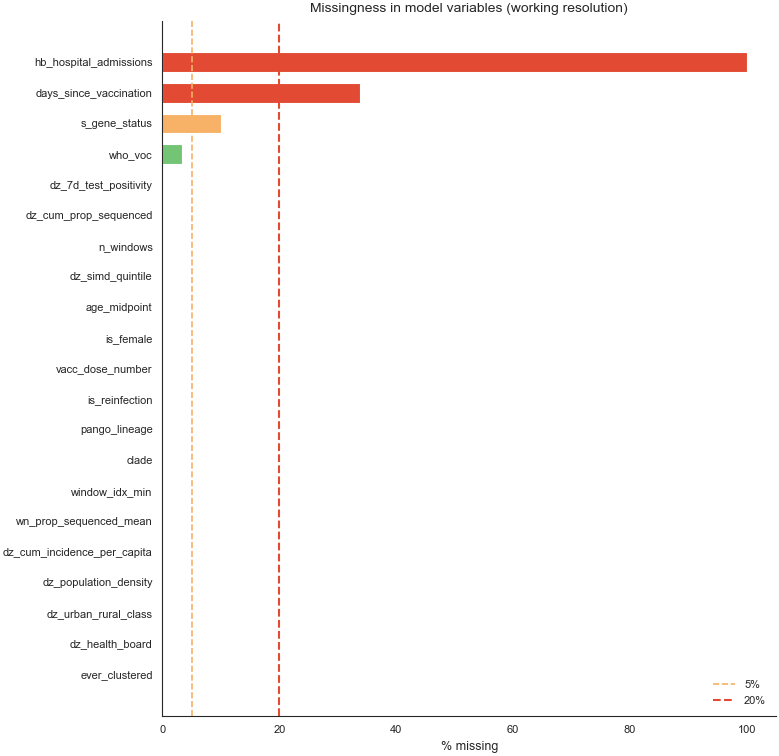

Variables with >5% missing:
              variable  pct_missing
         s_gene_status    10.094265
days_since_vaccination    33.808152
hb_hospital_admissions   100.000000

── Complete-case loss ────────────────────────────────────────────────────────
Complete cases: 0 / 324,194  (0.0%)

For high-missingness variables (e.g. test_reason, days_since_vaccination),
consider treating NaN as an explicit category or using multiple imputation.


In [68]:
MODEL_VARS = [
    "ever_clustered", "dz_simd_quintile",
    "age_midpoint", "is_female",
    "vacc_dose_number", "days_since_vaccination", "is_reinfection",
    "test_type", "test_reason", "s_gene_status",
    "who_voc", "clade", "pango_lineage",
    "dz_cum_prop_sequenced", "wn_prop_sequenced_mean",
    "dz_cum_incidence_per_capita", "dz_7d_test_positivity",
    "dz_population_density", "dz_urban_rural_class",
    "dz_health_board",
    "hb_hospital_admissions",
    "window_idx_min", "n_windows",
]
MODEL_VARS = [v for v in MODEL_VARS if v in wd.columns]

miss = (
    wd[MODEL_VARS]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
    .reset_index()
)
miss.columns = ["variable", "pct_missing"]

fig, ax = plt.subplots(figsize=(8, max(4, 0.37 * len(miss))))
colours = ["#e34a33" if v > 20 else "#f7b267" if v > 5 else "#74c476"
           for v in miss["pct_missing"]]
ax.barh(miss["variable"], miss["pct_missing"], color=colours, height=0.65)
ax.axvline(5,  color="#f7b267", ls="--", lw=1.2, label="5%")
ax.axvline(20, color="#e34a33", ls="--", lw=1.5, label="20%")
ax.set_xlabel("% missing")
ax.set_title("Missingness in model variables (working resolution)", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Variables with >5% missing:")
print(miss[miss["pct_missing"] > 5].to_string(index=False))

print("\n── Complete-case loss ────────────────────────────────────────────────────────")
n_cc = wd[MODEL_VARS].dropna().shape[0]
print(f"Complete cases: {n_cc:,} / {len(wd):,}  ({100*n_cc/len(wd):.1f}%)")
print("\nFor high-missingness variables (e.g. test_reason, days_since_vaccination),")
print("consider treating NaN as an explicit category or using multiple imputation.")


## 11  Resolution sensitivity — unadjusted SIMD OR across all resolutions

Before building the full adjusted model, check that the *direction* of the SIMD
association is consistent across all 8 Leiden resolutions. Inconsistency would suggest
the association is an artefact of a particular clustering granularity.


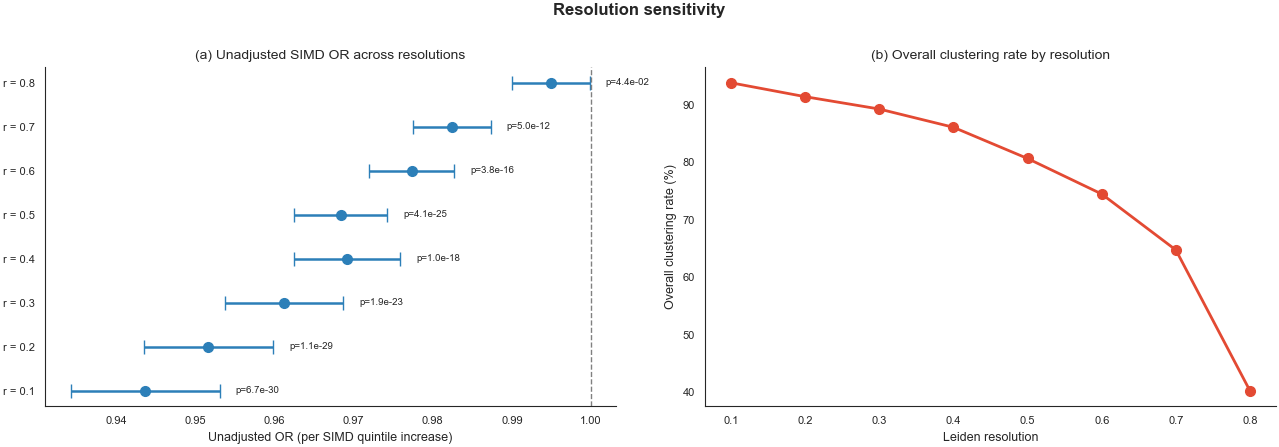

 resolution   rate  log_or      lo      hi      p
        0.1 0.9386 -0.0580 -0.0680 -0.0480 0.0000
        0.2 0.9144 -0.0496 -0.0582 -0.0410 0.0000
        0.3 0.8929 -0.0396 -0.0473 -0.0318 0.0000
        0.4 0.8611 -0.0313 -0.0383 -0.0244 0.0000
        0.5 0.8067 -0.0322 -0.0382 -0.0261 0.0000
        0.6 0.7449 -0.0229 -0.0284 -0.0174 0.0000
        0.7 0.6474 -0.0177 -0.0228 -0.0127 0.0000
        0.8 0.4020 -0.0051 -0.0100 -0.0001 0.0436

OR > 1: higher quintile (less deprived) → higher clustering probability
OR < 1: higher quintile (less deprived) → lower clustering probability


In [69]:
res_results = []
for res in sorted(adf["resolution"].unique()):
    d = adf.loc[adf["resolution"] == res, ["ever_clustered", "dz_simd_quintile"]].dropna()
    m = smf.logit("ever_clustered ~ dz_simd_quintile", data=d).fit(disp=0)
    ci = m.conf_int()
    res_results.append({
        "resolution" : res,
        "log_or"     : m.params["dz_simd_quintile"],
        "lo"         : ci.loc["dz_simd_quintile", 0],
        "hi"         : ci.loc["dz_simd_quintile", 1],
        "p"          : m.pvalues["dz_simd_quintile"],
        "rate"       : d["ever_clustered"].mean(),
    })

res_df = pd.DataFrame(res_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Forest plot of unadjusted OR per resolution
ax = axes[0]
y = range(len(res_df))
ax.errorbar(
    np.exp(res_df["log_or"]), y,
    xerr=[np.exp(res_df["log_or"]) - np.exp(res_df["lo"]),
          np.exp(res_df["hi"])     - np.exp(res_df["log_or"])],
    fmt="o", color="#2c7fb8", capsize=5, ms=7, lw=1.8,
)
ax.axvline(1, color="grey", ls="--", lw=1)
ax.set_yticks(list(y))
ax.set_yticklabels([f"r = {r}" for r in res_df["resolution"]])
ax.set_xlabel("Unadjusted OR (per SIMD quintile increase)")
ax.set_title("(a) Unadjusted SIMD OR across resolutions")
# Annotate
for i, row in res_df.iterrows():
    p_str = f"p={row['p']:.1e}"
    ax.text(np.exp(row["hi"])+0.002, i, p_str, va="center", fontsize=7)

# (b) Clustering rate by resolution (context)
ax = axes[1]
ax.plot(res_df["resolution"], 100*res_df["rate"], "o-", color="#e34a33", lw=2, ms=7)
ax.set_xlabel("Leiden resolution")
ax.set_ylabel("Overall clustering rate (%)")
ax.set_title("(b) Overall clustering rate by resolution")
ax.set_xticks(res_df["resolution"])

plt.suptitle("Resolution sensitivity", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(res_df[["resolution","rate","log_or","lo","hi","p"]].round(4).to_string(index=False))
print("\nOR > 1: higher quintile (less deprived) → higher clustering probability")
print("OR < 1: higher quintile (less deprived) → lower clustering probability")


The drop from r = 0.7 to r = 0.8 is disproportionately large — clustering rate falls from 64.7% to 40.2%, a 24-point drop, while the log-OR nearly vanishes (−0.018 to −0.005). This suggests r = 0.8 is pushing into a regime where the Leiden algorithm is dissolving genuinely connected clusters, and the outcome variable is becoming dominated by noise. This is useful information for justifying your choice of primary resolution — r = 0.3 sits in the stable middle of the range where the

What to report
For the paper, the forest plot from §11 of the notebook is the right display. In text, one sentence suffices: "The negative association between SIMD quintile and clustering probability was consistent in direction and significant across all eight Leiden resolutions (log-OR range: −0.058 to −0.005; all p ≤ 0.044), with attenuation at higher resolutions reflecting the reduced sensitivity of cluster detection rather than instability of the underlying association."
The primary analysis proceeds at r = 0.3. The resolution sensitivity is a supplementary figure.signal is strong and the clustering rate is plausible.

## 12  Model formulation synthesis

Use the findings from §§3–11 to complete this checklist before writing up the model.

---

### Outcome
`ever_clustered` (binary 0/1) — derived per `(sequence_id, resolution)`.
Model separately at each of the 8 resolutions (or include `resolution` as a moderator
with `(1|sequence_id)` to absorb the within-sequence correlation).

---

### Exposure coding
| Finding | Decision |
|---|---|
| **LRT (§4) p > 0.05** | Use `dz_simd_quintile` as a single linear term (OR per quintile) |
| **LRT p < 0.05** | Use quintile dummies (Q1 = reference) or spline on `dz_simd_rank` |

---

### Continuous covariate handling
Review the log-odds plots from §5 and apply the following:

| Variable | If LOWESS ≈ linear | If LOWESS curved |
|---|---|---|
| `age_midpoint` | Enter as-is | `bs(age_midpoint, df=3)` restricted cubic spline |
| `vacc_dose_number` | Linear term | Ordinal dummies (0, 1, 2, 3+) |
| `days_since_vaccination` | As-is (or log) | Log-transform or spline; set to 0 / add indicator for unvaccinated |
| `dz_population_density` | Always **log-transform** | Add quadratic if still curved |
| `dz_cum_prop_sequenced` | As-is | Logit-transform (bounded 0–1 variable) |
| `wn_prop_sequenced_mean` | As-is | Logit-transform |
| `dz_cum_incidence_per_capita` | As-is or log | Log-transform |
| `dz_7d_test_positivity` | As-is | Logit-transform |
| `window_idx_min` | **Do not use as linear** | Always use spline (`bs(window_idx_min, df=4)`) or wave-period dummies |
| `n_windows` | Linear or log | Include as offset or covariate |

---

### Categorical covariates
| Variable | Recommended handling |
|---|---|
| `who_voc` + `clade` | Fixed effects (dummy-coded) — preferred over raw `pango_lineage` |
| `test_type` | 2-level fixed effect (PCR / ANTIGEN) |
| `test_reason` | Fixed effect; treat NaN as explicit "Unknown" category if >5% missing |
| `dz_urban_rural_class` | Fixed effect (6-level); check VIF with `dz_population_density` |
| `dz_health_board` | Fixed or random effect `(1|dz_health_board)` — prefer random if using mixed model |

---

### Random effects / clustering structure
```
logit(ever_clustered) ~ [fixed effects]
                       + (1 | datazone)          # sequences from same DZ share neighbourhood
                       + (1 | dz_health_board)   # optional; or use HB fixed effects
```
Fit with `statsmodels` `MixedLM` (approximation) or `lme4::glmer` in R.

---

### Variables to drop or treat with caution
| Variable | Reason |
|---|---|
| `dz_simd_*_rank` (domain sub-indices) | Highly collinear with `dz_simd_quintile`; omit from same model |
| `dz_simd_decile` / `dz_simd_vigintile` | Redundant with `dz_simd_quintile`; pick one granularity |
| `dz_cum_prop_vaccinated` | Collinear with `vacc_dose_number` and `window_idx_min` |
| `hb_hospital_occupancy` | Collinear with `hb_hospital_admissions`; pick one |
| `s_gene_status` | Substantial missingness; correlated with `who_voc`; use with caution |

---

### Missing data strategy
- **Complete-case analysis** is the default.
- If missingness in `test_reason`, `days_since_vaccination`, or `s_gene_status` exceeds 10%
  *and* you wish to include these variables, consider **multiple imputation** (e.g. `mice` in R
  or `miceforest` / `sklearn.impute.IterativeImputer` in Python).
- Alternatively, add a binary "is_missing" indicator alongside each imputed variable.

---

### Recommended primary model skeleton (Python / statsmodels)

```python
import statsmodels.formula.api as smf
import numpy as np

formula = (
    "ever_clustered ~ "
    "dz_simd_quintile + "                         # exposure (linear or dummies)
    "age_midpoint + is_female + "                 # demographics
    "vacc_dose_number + is_reinfection + "        # vaccination / reinfection
    "test_type + test_reason + "                  # test characteristics
    "who_voc + clade + "                          # lineage / variant
    "dz_cum_prop_sequenced + wn_prop_sequenced_mean + "   # surveillance intensity
    "dz_cum_incidence_per_capita + dz_7d_test_positivity + "  # epidemic burden
    "np.log1p(dz_population_density) + "          # population density (log)
    "dz_urban_rural_class + "                     # urban-rural
    "dz_health_board + "                          # Health Board (fixed; or use random)
    "bs(window_idx_min, df=4) + "                 # epidemic phase (spline)
    "n_windows"                                   # opportunity
)

# At a single resolution:
model = smf.logit(formula, data=wd).fit(cov_type="cluster", cov_kwds={"groups": wd["datazone"]})

# Alternatively with DZ random intercept (mixed effects):
# model = smf.mixedlm(formula, data=wd, groups=wd["datazone"]).fit()
```

Present results as **OR with 95% CI and p-value** for `dz_simd_quintile`, repeating
the model across all 8 resolutions and displaying results in a forest plot (§11 template).
